In [1]:
!pip install numpy pandas matplotlib

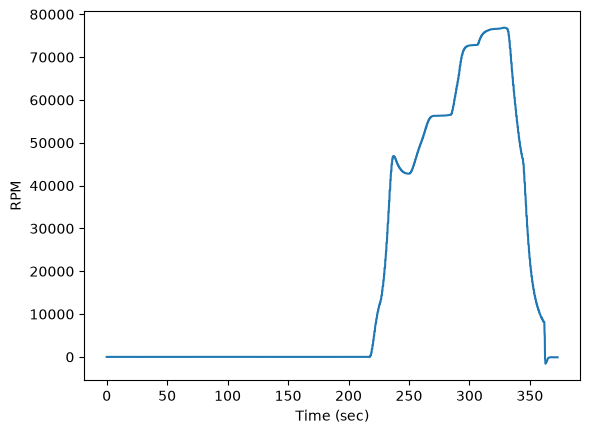

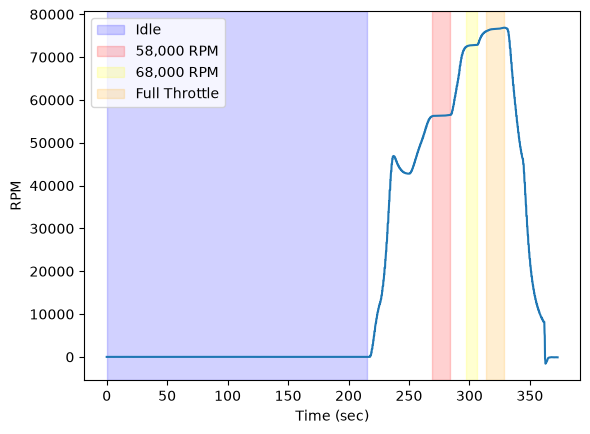

,T1 (K),T2 (K),T3 (K),T4 (K),P1 (kPa),P2 (kPa),P3 (kPa),P4 (kPa),Fuel Flow (L/hr),RPM,Thrust (N)
Idle,296.527486,296.372008,296.074565,296.855347,98.200000,98.198729,98.212399,98.200119,-7.961604e-19,3.645508e-16,-5.609112e-16
"58,000 RPM",287.386013,362.418293,923.823213,567.507267,98.172773,183.399307,181.911080,108.657053,1.508783e+01,5.633948e+04,3.431046e+01
"68,000 RPM",287.020044,410.908711,1010.990956,599.454156,98.171933,265.804800,263.607956,117.433867,2.129793e+01,7.272521e+04,6.405952e+01
Full Throttle,287.353013,440.032187,1050.241373,614.762120,98.174827,290.283253,287.694133,120.174467,2.366995e+01,7.655945e+04,7.202371e+01


,RPM,p2/p1,h1 (kJ/kg),h2 (kJ/kg),h2s (kJ/kg),eta_c
Idle,0.000,1.000,296.704,296.547,296.703,NaN
"58,000 RPM",56339.478,1.868,287.536,363.020,343.916,0.747
"68,000 RPM",72725.215,2.708,287.168,412.041,382.094,0.760
Full Throttle,76559.447,2.957,287.502,441.643,392.288,0.680


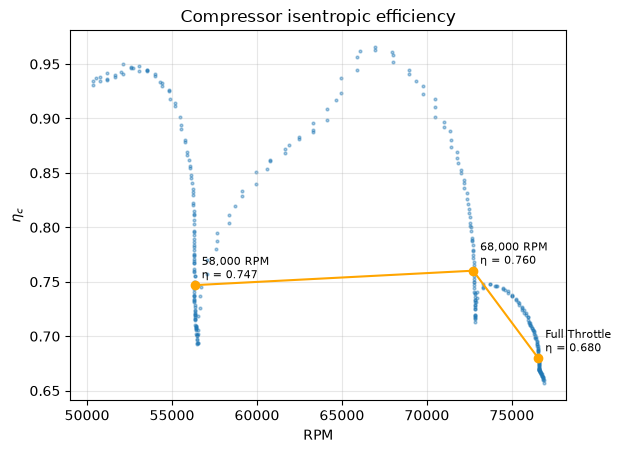

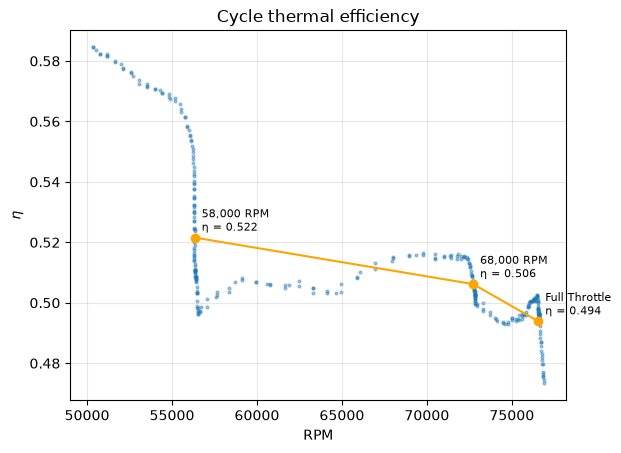

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Air import air

df = pd.read_csv("aYdata.tsv", sep='\t', skiprows=2)

Pamb = 982 # hPa
Tamb = 23.2 # C
df['Time (sec)'] -= df['Time (sec)'][0]
df['P1 (kPa)'] -= df['P1 (kPa)'][0]
df['P2 (kPa)'] -= df['P2 (kPa)'][0]
df['P3 (kPa)'] -= df['P3 (kPa)'][0]
df['P4 (kPa)'] -= df['P4 (kPa)'][0]
df['P1 (kPa)'] += Pamb / 10
df['P2 (kPa)'] += Pamb / 10
df['P3 (kPa)'] += Pamb / 10
df['P4 (kPa)'] += Pamb / 10

df['T1 (C)'] -= df['T1 (C)'][0]
df['T2 (C)'] -= df['T2 (C)'][0]
df['T3 (C)'] -= df['T3 (C)'][0]
df['T4 (C)'] -= df['T4 (C)'][0]
df['T1 (C)'] += Tamb
df['T2 (C)'] += Tamb
df['T3 (C)'] += Tamb 
df['T4 (C)'] += Tamb


df['T1 (C)'] += 273.15
df['T2 (C)'] += 273.15
df['T3 (C)'] += 273.15
df['T4 (C)'] += 273.15
df.rename(columns={'T1 (C)': 'T1 (K)', 'T2 (C)': 'T2 (K)',
                  'T3 (C)': 'T3 (K)', 'T4 (C)': 'T4 (K)'}, inplace=True)

df = df[(df['T3 (K)'] >= 200) & (df['T4 (K)'] >= 200)].copy()

plt.plot(df['Time (sec)'], df['RPM'])
plt.xlabel('Time (sec)')
plt.ylabel('RPM')
plt.show()

plt.plot(df['Time (sec)'], df['RPM'])
plt.xlabel('Time (sec)')
plt.ylabel('RPM')
plt.axvspan(0, 215, alpha=0.18, color='blue', label='Idle')
plt.axvspan(269, 284, alpha=0.18, color='red', label='58,000 RPM')
plt.axvspan(297, 306, alpha=0.18, color='yellow', label='68,000 RPM')
plt.axvspan(314, 329, alpha=0.18, color='orange', label='Full Throttle')
plt.legend()
plt.show()

T = df['Time (sec)']
mask_tare = (T >=0) & (T <= 215)
df['Fuel Flow  (L/hr)'] -= np.mean(df['Fuel Flow  (L/hr)'][mask_tare])
df['RPM'] -= np.mean(df['RPM'][mask_tare])
df['Thrust (N)'] -= np.mean(df['Thrust (N)'][mask_tare])

mask_setting_1 = (T >=269) & (T <= 284)
mask_setting_2 = (T >=297) & (T <= 306)
mask_setting_3 = (T >=314) & (T <= 329)
masks = [(mask_tare, 'Idle'), (mask_setting_1, '58,000 RPM'), (mask_setting_2, '68,000 RPM'), (mask_setting_3, 'Full Throttle')]

TableValues = {
    Run: {
        header: np.mean(df[header][mask])
        for header in df.columns[1:]
    }
    for i, (mask, Run) in enumerate(masks)
}

df_avg = pd.DataFrame.from_dict(TableValues, orient='index')

display(df_avg)

p1 = df['P1 (kPa)']
p2 = df['P2 (kPa)']

st1 = air(T=df['T1 (K)'])
st2 = air(T=df['T2 (K)'])
df['h1 (kJ/kg)'] = st1['h']
df['h2 (kJ/kg)'] = st2['h']
df['pr1'] = st1['pr']
df['pr2s'] = df['pr1'] * p2 / p1
df['h2s (kJ/kg)'] = air(pr=df['pr2s'])['h']

dh = df['h2 (kJ/kg)'] - df['h1 (kJ/kg)']
df['eta_c'] = np.where(dh > 1, (df['h2s (kJ/kg)'] - df['h1 (kJ/kg)']) / dh, np.nan)

idx_max = df['RPM'].idxmax()

running = (df['RPM'] > 50000) & (df['Time (sec)'] < df.loc[idx_max, 'Time (sec)'])
plt.scatter(df.loc[running, 'RPM'], df.loc[running, 'eta_c'], s=4, alpha=0.4, label='All samples')
plt.xlabel('RPM'); plt.ylabel(r'$\eta_c$'); plt.grid(alpha=0.3)

p1 = df_avg['P1 (kPa)']
p2 = df_avg['P2 (kPa)']

st1 = air(T=df_avg['T1 (K)'])
st2 = air(T=df_avg['T2 (K)'])
df_avg['h1 (kJ/kg)'] = st1['h']
df_avg['h2 (kJ/kg)'] = st2['h']
df_avg['pr1'] = st1['pr']
df_avg['p2/p1'] = p2 / p1
df_avg['pr2s'] = df_avg['pr1'] * df_avg['p2/p1']
df_avg['h2s (kJ/kg)'] = air(pr=df_avg['pr2s'])['h']

dh = df_avg['h2 (kJ/kg)'] - df_avg['h1 (kJ/kg)']
df_avg['eta_c'] = np.where(dh > 1, (df_avg['h2s (kJ/kg)'] - df_avg['h1 (kJ/kg)']) / dh, np.nan)

display(df_avg[['RPM', 'p2/p1', 'h1 (kJ/kg)', 'h2 (kJ/kg)', 'h2s (kJ/kg)', 'eta_c']].round(3))

running = df_avg['RPM'] > 1000
plt.plot(df_avg.loc[running, 'RPM'], df_avg.loc[running, 'eta_c'], 'o-', color='orange')
for name, row in df_avg[running].iterrows():
    plt.annotate(f"{name}\nη = {row['eta_c']:.3f}", (row['RPM'], row['eta_c']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.xlabel('RPM'); plt.ylabel(r'$\eta_c$'); plt.title('Compressor isentropic efficiency')
plt.grid(alpha=0.3)
plt.show()

for d in (df, df_avg):
    st3 = air(T=d['T3 (K)'])
    st4 = air(T=d['T4 (K)'])
    d['h3 (kJ/kg)'] = st3['h']
    d['h4 (kJ/kg)'] = st4['h']
    d['eta_th'] = ((d['h3 (kJ/kg)'] - d['h4 (kJ/kg)']) - (d['h2 (kJ/kg)'] - d['h1 (kJ/kg)']))/((d['h3 (kJ/kg)'] - d['h2 (kJ/kg)']))

running = (df['RPM'] > 50000) & (df['Time (sec)'] < df.loc[idx_max, 'Time (sec)'])
plt.scatter(df.loc[running, 'RPM'], df.loc[running, 'eta_th'], s=4, alpha=0.4, label='All samples')
plt.xlabel('RPM'); plt.ylabel(r'$\eta$'); plt.title('Cycle thermal efficiency')
plt.grid(alpha=0.3)

running = df_avg['RPM'] > 1000
plt.plot(df_avg.loc[running, 'RPM'], df_avg.loc[running, 'eta_th'], 'o-', color='orange')
for name, row in df_avg[running].iterrows():
    plt.annotate(f"{name}\nη = {row['eta_th']:.3f}", (row['RPM'], row['eta_th']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.xlabel('RPM'); plt.ylabel(r'$\eta$'); plt.title('Cycle thermal efficiency')
plt.grid(alpha=0.3)
plt.show()